# Lecture 16 — Training Large Models

**CMU 10-414/714, Deep Learning Systems (lecture by Tianqi Chen)**
Companion notebook · Sangram Lembe

Two problems, two halves:

1. **Memory** — fit a deeper network into a fixed amount of memory. Activation checkpointing is
   implemented here for real, and its gradients are checked to be *identical* to ordinary backprop
   while holding far fewer activations.
2. **Scale** — spread training over many GPUs. There is one CPU here, so pipelines, allreduce and the
   parameter server are **simulated** faithfully: data-parallel training is shown to produce exactly
   the same weights as single-device training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(0)

## 1. Where the memory goes

Training holds three things: the **weights**, the **optimizer state** (momentum keeps one extra number
per weight, Adam two), and the **activations** saved for the backward pass. For a deep MLP:

In [2]:
def memory_mb(depth, width, batch, optimizer="adam", bytes_per=4):
    weights = depth * width * width
    state = {"sgd": 0, "momentum": 1, "adam": 2}[optimizer] * weights
    activations = depth * batch * width            # one saved activation per layer
    to_mb = lambda n: n * bytes_per / 1e6
    return to_mb(weights), to_mb(state), to_mb(activations)

print(f"{'depth':>6}{'weights MB':>12}{'Adam state MB':>15}{'activations MB':>16}")
for depth in (10, 100, 1000):
    w, s, a = memory_mb(depth, width=1024, batch=256)
    print(f"{depth:>6}{w:>12.0f}{s:>15.0f}{a:>16.0f}")

 depth  weights MB  Adam state MB  activations MB
    10          42             84              10
   100         419            839             105
  1000        4194           8389            1049


Every column grows with depth, and Adam's state alone is twice the weights. For this wide MLP the
weights actually dominate. Convolutional networks are the opposite: a filter is tiny, but every layer's
feature map covers the whole image.

In [3]:
# one 3x3 convolution, 64 -> 64 channels, on a batch of 32 images of 224x224 (NHWC)
weights = 3 * 3 * 64 * 64
acts    = 32 * 224 * 224 * 64
print(f"conv layer weights     : {weights * 4 / 1e6:8.2f} MB")
print(f"its output activations : {acts * 4 / 1e6:8.1f} MB   ({acts / weights:,.0f}x the weights)")

conv layer weights     :     0.15 MB
its output activations :    411.0 MB   (2,788x the weights)


That is the regime activation checkpointing is built for: activations hundreds of times larger than the
weights that produce them.

## 2. Inference needs only two buffers

Without gradients, each layer needs only the previous layer's output, so two buffers can be reused
forever — the lecture's ping-pong idea. `np.matmul(..., out=...)` writes into a pre-allocated buffer.

In [4]:
depth, width, batch = 50, 128, 16
Ws = [rng.normal(0, np.sqrt(2 / width), (width, width)) for _ in range(depth)]
x = rng.normal(size=(batch, width))

def forward_normal(x):
    for W in Ws:
        x = np.maximum(0, x @ W)                    # a fresh array every layer
    return x

def forward_pingpong(x):
    A, B = np.empty((batch, width)), np.empty((batch, width))   # the ONLY two buffers
    np.copyto(A, x)
    src, dst = A, B
    for W in Ws:
        np.matmul(src, W, out=dst)                  # linear layer into the other buffer
        np.maximum(dst, 0, out=dst)                 # ReLU in place
        src, dst = dst, src                         # swap roles
    return src

print("same result:", np.allclose(forward_normal(x), forward_pingpong(x)))
print(f"activation buffers used: 2, for a {depth}-layer network")

same result: True
activation buffers used: 2, for a 50-layer network


## 3. Training keeps every activation

The gradient of each weight needs that layer's *input* from the forward pass, so ordinary backprop must
keep all of them. A small MLP with an instrumented forward/backward:

In [5]:
def layer_forward(z, W):
    return np.maximum(0, z @ W)

def layer_backward(z_in, W, g_out):
    """Given a layer's input and the gradient at its output: grads for W and for the input."""
    pre = z_in @ W
    d = g_out * (pre > 0)
    return z_in.T @ d, d @ W.T

def backprop_full(x, Ws, g_top):
    acts, z = [x], x
    for W in Ws:
        z = layer_forward(z, W); acts.append(z)            # keep EVERY activation
    grads, g = [None] * len(Ws), g_top
    for i in reversed(range(len(Ws))):
        grads[i], g = layer_backward(acts[i], Ws[i], g)
    return grads, len(acts), len(Ws)                       # grads, peak activations, forward calls

n = 64
Ws = [rng.normal(0, np.sqrt(2 / 32), (32, 32)) for _ in range(n)]
x = rng.normal(size=(8, 32))
g_top = rng.normal(size=(8, 32))
full_grads, peak_full, fwd_full = backprop_full(x, Ws, g_top)
print(f"{n} layers, ordinary backprop: {peak_full} activations alive at the peak")

64 layers, ordinary backprop: 65 activations alive at the peak


## 4. Activation checkpointing

Keep every $k$-th activation during the forward pass. Then, working backwards one segment at a time:
recompute that segment from its checkpoint, backprop through it, and free it. At the peak you hold
$n/k$ checkpoints plus one segment of $k$.

In [6]:
def backprop_checkpointed(x, Ws, g_top, k):
    n = len(Ws)
    checkpoints, z, fwd_calls = {0: x}, x, 0
    for i, W in enumerate(Ws, start=1):                    # forward: keep every k-th only
        z = layer_forward(z, W); fwd_calls += 1
        if i % k == 0 and i < n:
            checkpoints[i] = z
    grads, g, peak = [None] * n, g_top, 0
    for start in sorted(checkpoints, reverse=True):        # segments, last to first
        end = min(start + k, n)
        seg = [checkpoints[start]]
        for i in range(start, end):                        # recompute this segment
            seg.append(layer_forward(seg[-1], Ws[i])); fwd_calls += 1
        peak = max(peak, len(checkpoints) + len(seg))      # checkpoints + live segment
        for i in reversed(range(start, end)):              # backprop through it
            grads[i], g = layer_backward(seg[i - start], Ws[i], g)
        del seg                                            # free before the next segment
    return grads, peak, fwd_calls

ck_grads, peak, calls = backprop_checkpointed(x, Ws, g_top, k=8)
same = all(np.array_equal(a, b) for a, b in zip(full_grads, ck_grads))
print(f"gradients bit-for-bit identical to ordinary backprop: {same}")
print(f"peak activations: {peak_full} -> {peak}")
print(f"forward layer calls: {fwd_full} -> {calls}  (one extra forward pass)")

gradients bit-for-bit identical to ordinary backprop: True
peak activations: 65 -> 17
forward layer calls: 64 -> 128  (one extra forward pass)


Same gradients exactly, a fraction of the memory, at the cost of running the forward pass twice. Now
sweep the segment length $k$:

   k  peak activations   n/k + k  forward calls
   1                66        65            128
   2                35        34            128
   4                21        20            128
   8                17        16            128
  16                21        20            128
  32                35        34            128
  64                66        65            128


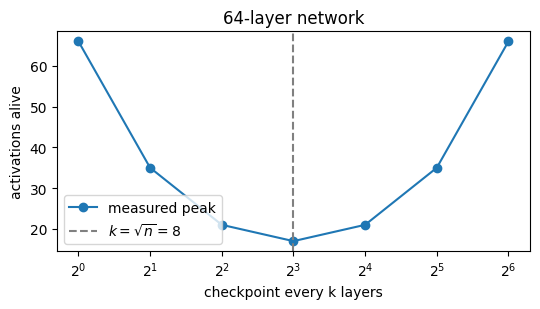

In [7]:
print(f"{'k':>4}{'peak activations':>18}{'n/k + k':>10}{'forward calls':>15}")
results = []
for k in (1, 2, 4, 8, 16, 32, 64):
    _, peak, calls = backprop_checkpointed(x, Ws, g_top, k)
    results.append((k, peak))
    print(f"{k:>4}{peak:>18}{n // k + k:>10}{calls:>15}")

ks, peaks = zip(*results)
plt.figure(figsize=(5.5, 3.2))
plt.plot(ks, peaks, "o-", label="measured peak")
plt.axvline(np.sqrt(n), ls="--", color="gray", label=r"$k=\sqrt{n}=8$")
plt.xscale("log", base=2); plt.xlabel("checkpoint every k layers"); plt.ylabel("activations alive")
plt.legend(); plt.title(f"{n}-layer network"); plt.tight_layout(); plt.show()

The measured peak follows $n/k + k$ and is lowest at $k = \sqrt{n} = 8$: 64 layers need 17
activations instead of 65. Small $k$ keeps too many checkpoints; large $k$ makes each recomputed segment
too long.

### How much extra time?

Exactly one extra forward pass. A backward pass costs roughly twice a forward pass (it computes two
matrix products per layer instead of one), which can be measured directly:

In [8]:
import time
def best(fn, r=5):
    t = float("inf")
    for _ in range(r):
        s = time.perf_counter(); fn(); t = min(t, time.perf_counter() - s)
    return t

Wb = [rng.normal(0, np.sqrt(2 / 512), (512, 512)) for _ in range(20)]
xb, gb = rng.normal(size=(256, 512)), rng.normal(size=(256, 512))
t_full = best(lambda: backprop_full(xb, Wb, gb))
t_ck = best(lambda: backprop_checkpointed(xb, Wb, gb, k=4))
print(f"ordinary backprop    : {t_full*1e3:7.1f} ms")
print(f"checkpointed (k = 4) : {t_ck*1e3:7.1f} ms   (+{(t_ck/t_full - 1)*100:.0f}%)")

ordinary backprop    :   221.4 ms
checkpointed (k = 4) :   262.0 ms   (+18%)


The lecture quotes about 20–25%; the exact figure depends on how expensive the forward pass is
relative to the backward pass on a given machine. Either way it is a modest price for memory that
grows with $\sqrt{n}$ instead of $n$.

## 5. Model parallelism needs a pipeline

Split the layers across $W$ workers. With one batch, only one worker is busy at a time. Split the
batch into $M$ micro-batches and the workers overlap:

In [9]:
def pipeline_schedule(W, M):
    steps = M + W - 1
    grid = [["." for _ in range(steps)] for _ in range(W)]
    for w in range(W):
        for m in range(M):
            grid[w][m + w] = str(m + 1)
    return grid, M / steps

grid, util = pipeline_schedule(W=3, M=4)
for w, row in enumerate(grid):
    print(f"worker {w}: " + " ".join(f"{c:>2}" for c in row))
print("('.' = idle, the pipeline bubble)\n")

print(f"{'workers':>8}{'micro-batches':>15}{'time steps':>12}{'each worker busy':>18}")
for M in (1, 4, 8, 32):
    _, util = pipeline_schedule(4, M)
    print(f"{4:>8}{M:>15}{M + 3:>12}{util:>18.0%}")

worker 0:  1  2  3  4  .  .
worker 1:  .  1  2  3  4  .
worker 2:  .  .  1  2  3  4
('.' = idle, the pipeline bubble)

 workers  micro-batches  time steps  each worker busy
       4              1           4               25%
       4              4           7               57%
       4              8          11               73%
       4             32          35               91%


## 6. Data parallelism with allreduce

Every worker holds a full copy of the model and processes its own slice of the mini-batch. `allreduce`
sums an array across workers and gives every worker the result — the lecture's example first:

In [10]:
def allreduce(arrays):
    """Every worker passes an array; every worker gets back the element-wise sum."""
    total = np.sum(arrays, axis=0)
    return [total.copy() for _ in arrays]

print(allreduce([np.array([1, 2, 3]), np.array([1, 0, 1])]))

[array([2, 2, 4]), array([2, 2, 4])]


Now train softmax regression on digits two ways — on one device, and on 4 simulated workers that each
get a quarter of every mini-batch, sum gradients with allreduce, and update locally. If data
parallelism is correct, the weights must come out **identical**.

In [11]:
digits = load_digits()
X, y = digits.data / 16.0, digits.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

def grad_sum(theta, Xb, yb):
    """SUM (not mean) of per-example cross-entropy gradients - so pieces add up."""
    z = Xb @ theta; z -= z.max(1, keepdims=True)
    p = np.exp(z); p /= p.sum(1, keepdims=True)
    p[np.arange(len(yb)), yb] -= 1
    return Xb.T @ p

def train(n_workers, epochs=20, B=64, lr=0.5):
    replicas = [np.zeros((64, 10)) for _ in range(n_workers)]     # one copy per worker
    order_rng = np.random.default_rng(1)
    for _ in range(epochs):
        order = order_rng.permutation(len(Xtr))
        for i in range(0, len(order), B):
            idx = order[i:i + B]
            shards = np.array_split(idx, n_workers)               # each worker's slice
            local = [grad_sum(replicas[w], Xtr[s], ytr[s]) for w, s in enumerate(shards)]
            summed = allreduce(local)                              # the only communication
            for w in range(n_workers):
                replicas[w] -= lr * summed[w] / len(idx)
    return replicas

single = train(1)[0]
parallel = train(4)
print("all 4 replicas identical to each other :", all(np.allclose(parallel[0], r) for r in parallel))
print("identical to single-device training     :", np.allclose(single, parallel[0]))
print("test accuracy                           :", np.mean((Xte @ parallel[0]).argmax(1) == yte))

all 4 replicas identical to each other : True
identical to single-device training     : True
test accuracy                           : 0.9488888888888889


The model code never changed — only the gradient step gained an allreduce. That is why data
parallelism is the default way to scale training.

## 7. The parameter server, and stragglers

Workers push gradients to a server, which sums them, updates, and lets workers pull the new weights.
The advantage: it does not have to wait for a slow worker. Simulate 10 workers where one is always late,
and a server that updates as soon as 9 gradients arrive:

In [12]:
def train_ps(n_workers=10, wait_for=10, epochs=20, B=100, lr=0.5, crash_at=None):
    server_theta = np.zeros((64, 10))                     # the server holds the weights
    r = np.random.default_rng(2)
    restarted = False
    for ep in range(epochs):
        order = r.permutation(len(Xtr))
        for i in range(0, len(order), B):
            idx = order[i:i + B]
            shards = np.array_split(idx, n_workers)
            arrived = list(range(n_workers))[:wait_for]   # worker 9 is the straggler
            g = sum(grad_sum(server_theta, Xtr[shards[w]], ytr[shards[w]]) for w in arrived)
            n_used = sum(len(shards[w]) for w in arrived)
            server_theta -= lr * g / n_used               # server-side update
        if crash_at == ep:
            worker_copy = server_theta.copy()             # a restarted worker just pulls
            restarted = np.array_equal(worker_copy, server_theta)
    acc = np.mean((Xte @ server_theta).argmax(1) == yte)
    return acc, restarted

acc_all, _ = train_ps(wait_for=10)
acc_skip, ok = train_ps(wait_for=9, crash_at=5)
print(f"wait for all 10 workers      : test accuracy {acc_all:.3f}")
print(f"ignore the straggler (9/10)  : test accuracy {acc_skip:.3f}")
print(f"crashed worker resumed by pulling the server's weights: {ok}")

wait for all 10 workers      : test accuracy 0.947
ignore the straggler (9/10)  : test accuracy 0.944
crashed worker resumed by pulling the server's weights: True


Dropping the straggler's share of each batch barely changes the result, and nobody had to wait. A
worker that restarts needs nothing except the server's current weights.

## 8. Overlapping communication with computation

The backward pass finishes the **last** layer's gradient first. If sending waits until all gradients
exist, the network sits idle during the backward pass. A simple timeline model, with each layer's
gradient taking 2 units to compute and 3 to send:

In [13]:
def finish_time(n_layers, t_compute, t_send, overlap):
    if not overlap:
        return n_layers * t_compute + n_layers * t_send          # compute all, then send all
    t_net, t_done = 0, 0
    for i in range(n_layers):                                   # gradients appear one by one
        t_done = (i + 1) * t_compute
        t_net = max(t_net, t_done) + t_send                     # send as soon as ready
    return t_net

for layers in (4, 16):
    seq = finish_time(layers, 2, 3, overlap=False)
    ovl = finish_time(layers, 2, 3, overlap=True)
    print(f"{layers:>2} layers: sequential {seq:>3} units   overlapped {ovl:>3} units"
          f"   ({(1 - ovl/seq)*100:.0f}% less time)")

 4 layers: sequential  20 units   overlapped  14 units   (30% less time)
16 layers: sequential  80 units   overlapped  50 units   (38% less time)


Overlapping hides most of the computation behind the communication. The lecture adds one refinement:
the next forward pass needs layer 1's weights *first*, but layer 1's gradient arrives *last* — so when
gradients queue up, send the early layers' first.

## Summary

- Training memory is weights, optimizer state (Adam doubles the weights) and activations.
- Inference ran a 50-layer network with two reusable buffers.
- Checkpointing every $k$ layers gave **bit-for-bit identical** gradients; the measured peak followed
  $n/k + k$, lowest at $k=\sqrt{n}$, for one extra forward pass.
- Pipelining: 4 workers are busy 25% of the time with one micro-batch, 91% with 32.
- Data parallelism with allreduce produced weights **identical** to single-device training.
- A parameter server that ignored a straggler reached the same accuracy without waiting.
- Overlapping sends with backward computation cut the modelled step time substantially.